# Heart Failure Prediction - EDA & Model Building

**Dataset:** Heart Failure Clinical Records (`heart_failure_clinical_records_dataset.csv`)
**Target:** `DEATH_EVENT` (binary classification - did the patient die during follow-up?)

## Workflow
1. Load data
2. Exploratory Data Analysis (EDA)
3. Train/Test split
4. Baseline model + Cross-Validation (via sklearn **Pipeline**)
5. Hyperparameter tuning (RandomizedSearchCV + GridSearchCV) on the Pipeline
6. Best model evaluation
7. Save the full **Pipeline** (`scaler + model`) as a single `pipeline.pkl`
8. Sample predictions + predict_proba


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Data

In [2]:
DATA_PATH = "heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.00,0,582,0,20,1,265000.00,1.90,130,1,0,4,1
1,55.00,0,7861,0,38,0,263358.03,1.10,136,1,0,6,1
2,65.00,0,146,0,20,0,162000.00,1.30,129,1,1,7,1
3,50.00,1,111,0,20,0,210000.00,1.90,137,1,0,7,1
4,65.00,1,160,1,20,0,327000.00,2.70,116,0,0,8,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.00,60.83,11.89,40.00,51.00,60.00,70.00,95.00
anaemia,299.00,0.43,0.50,0.00,0.00,0.00,1.00,1.00
creatinine_phosphokinase,299.00,581.84,970.29,23.00,116.50,250.00,582.00,7861.00
diabetes,299.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
ejection_fraction,299.00,38.08,11.83,14.00,30.00,38.00,45.00,80.00
high_blood_pressure,299.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00
platelets,299.00,263358.03,97804.24,25100.00,212500.00,262000.00,303500.00,850000.00
serum_creatinine,299.00,1.39,1.03,0.50,0.90,1.10,1.40,9.40
serum_sodium,299.00,136.63,4.41,113.00,134.00,137.00,140.00,148.00
sex,299.00,0.65,0.48,0.00,0.00,1.00,1.00,1.00


## 2. Exploratory Data Analysis (EDA)

In [5]:
# Check unique values of binary columns
binary_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking", "DEATH_EVENT"]
for c in binary_cols:
    print(f"{c}: {sorted(df[c].unique())} -> {df[c].value_counts().to_dict()}")

anaemia: [np.int64(0), np.int64(1)] -> {0: 170, 1: 129}
diabetes: [np.int64(0), np.int64(1)] -> {0: 174, 1: 125}
high_blood_pressure: [np.int64(0), np.int64(1)] -> {0: 194, 1: 105}
sex: [np.int64(0), np.int64(1)] -> {1: 194, 0: 105}
smoking: [np.int64(0), np.int64(1)] -> {0: 203, 1: 96}
DEATH_EVENT: [np.int64(0), np.int64(1)] -> {0: 203, 1: 96}


In [6]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Duplicate rows: 0


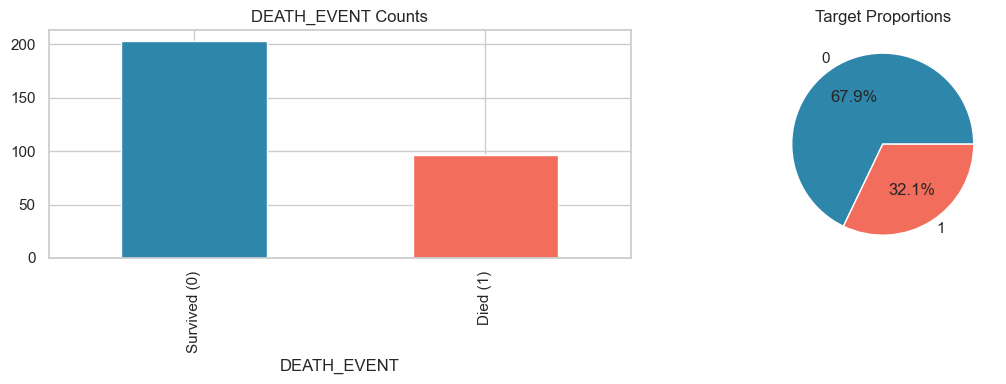

DEATH_EVENT
0   67.89
1   32.11
Name: proportion, dtype: float64


In [7]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["DEATH_EVENT"].value_counts().plot(kind="bar", ax=axes[0], color=["#2E86AB", "#F26D5B"])
axes[0].set_title("DEATH_EVENT Counts")
axes[0].set_xticklabels(["Survived (0)", "Died (1)"])
df["DEATH_EVENT"].value_counts().plot(kind="pie", ax=axes[1], autopct="%.1f%%", colors=["#2E86AB", "#F26D5B"])
axes[1].set_title("Target Proportions")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

print(df["DEATH_EVENT"].value_counts(normalize=True) * 100)

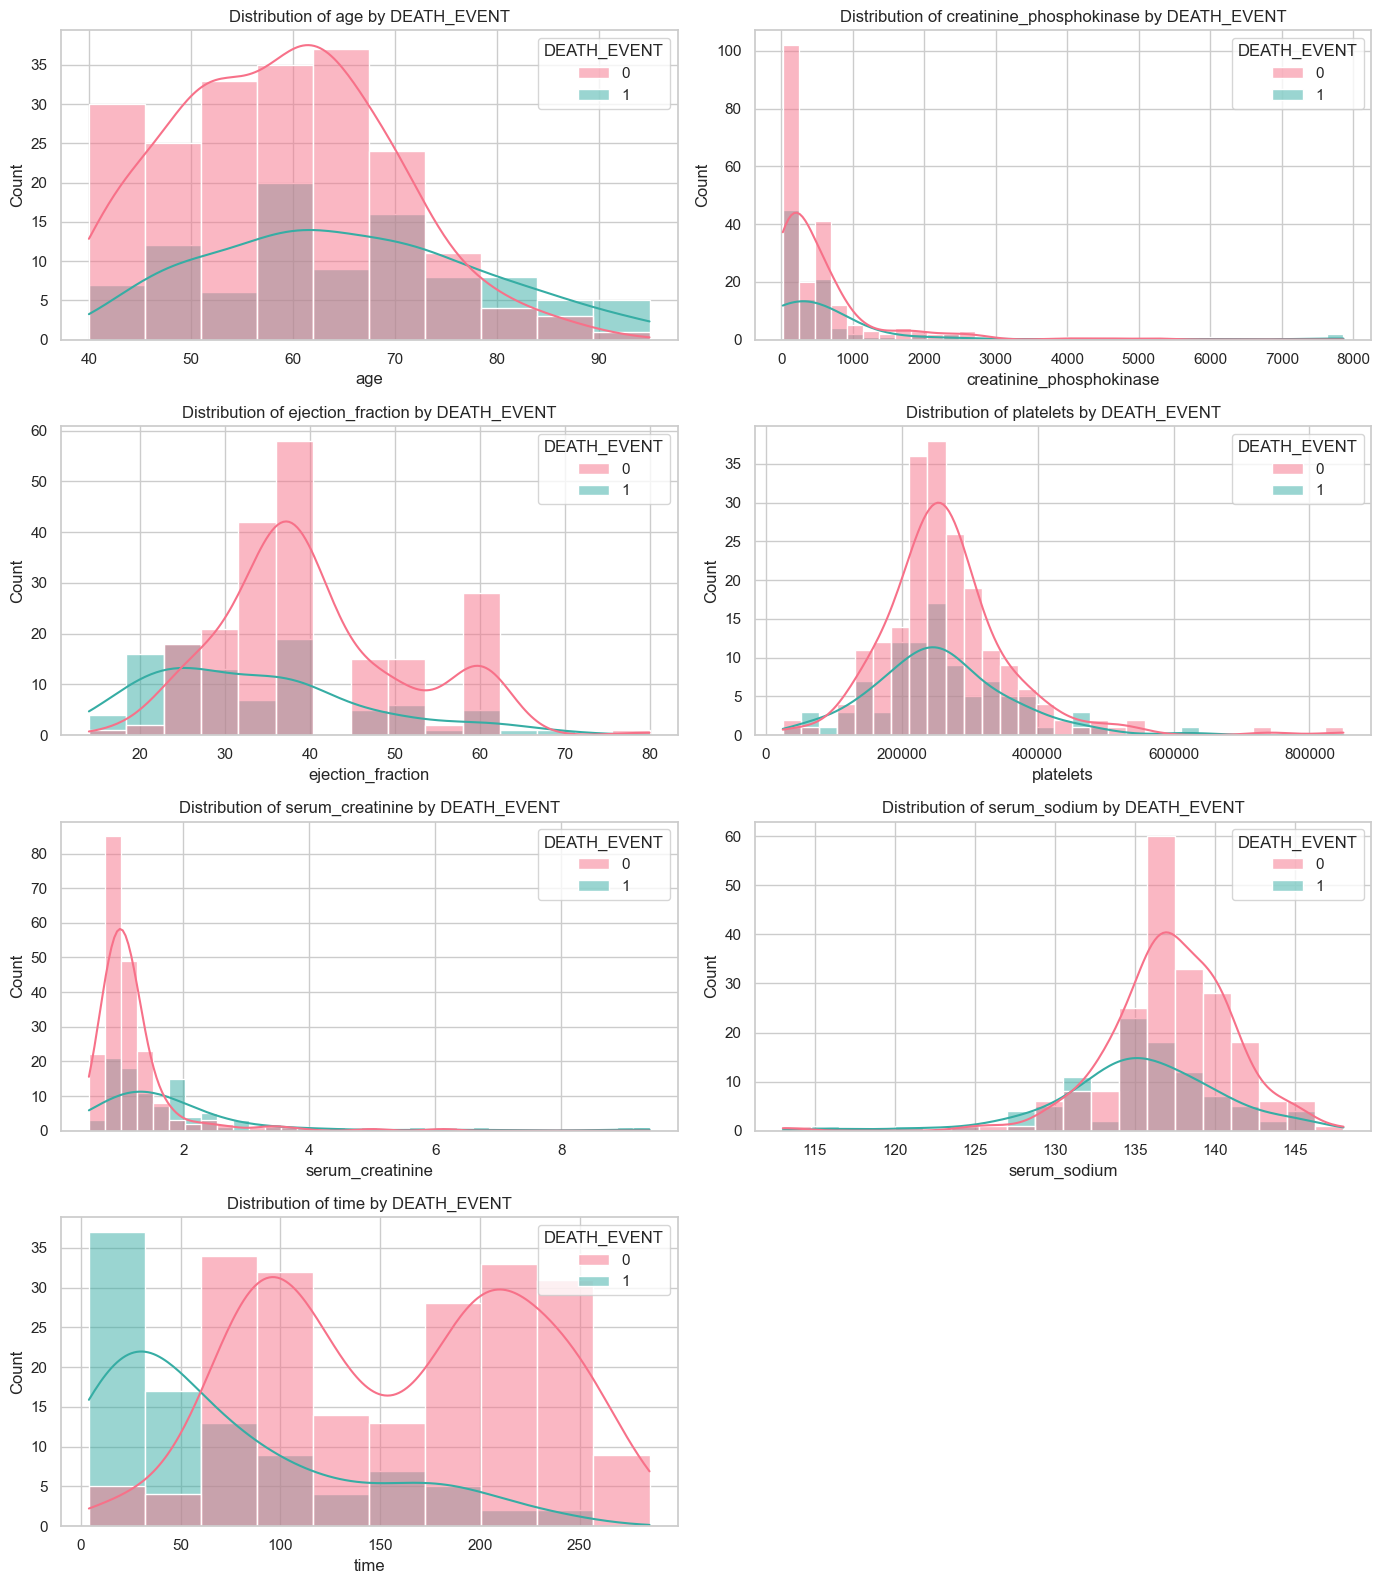

In [8]:
# Distribution of numerical features by target
num_cols = ["age", "creatinine_phosphokinase", "ejection_fraction", "platelets",
            "serum_creatinine", "serum_sodium", "time"]
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(data=df, x=col, hue="DEATH_EVENT", kde=True, ax=ax, palette="husl")
    ax.set_title(f"Distribution of {col} by DEATH_EVENT")
fig.delaxes(axes.flatten()[-1])
plt.tight_layout()
plt.show()

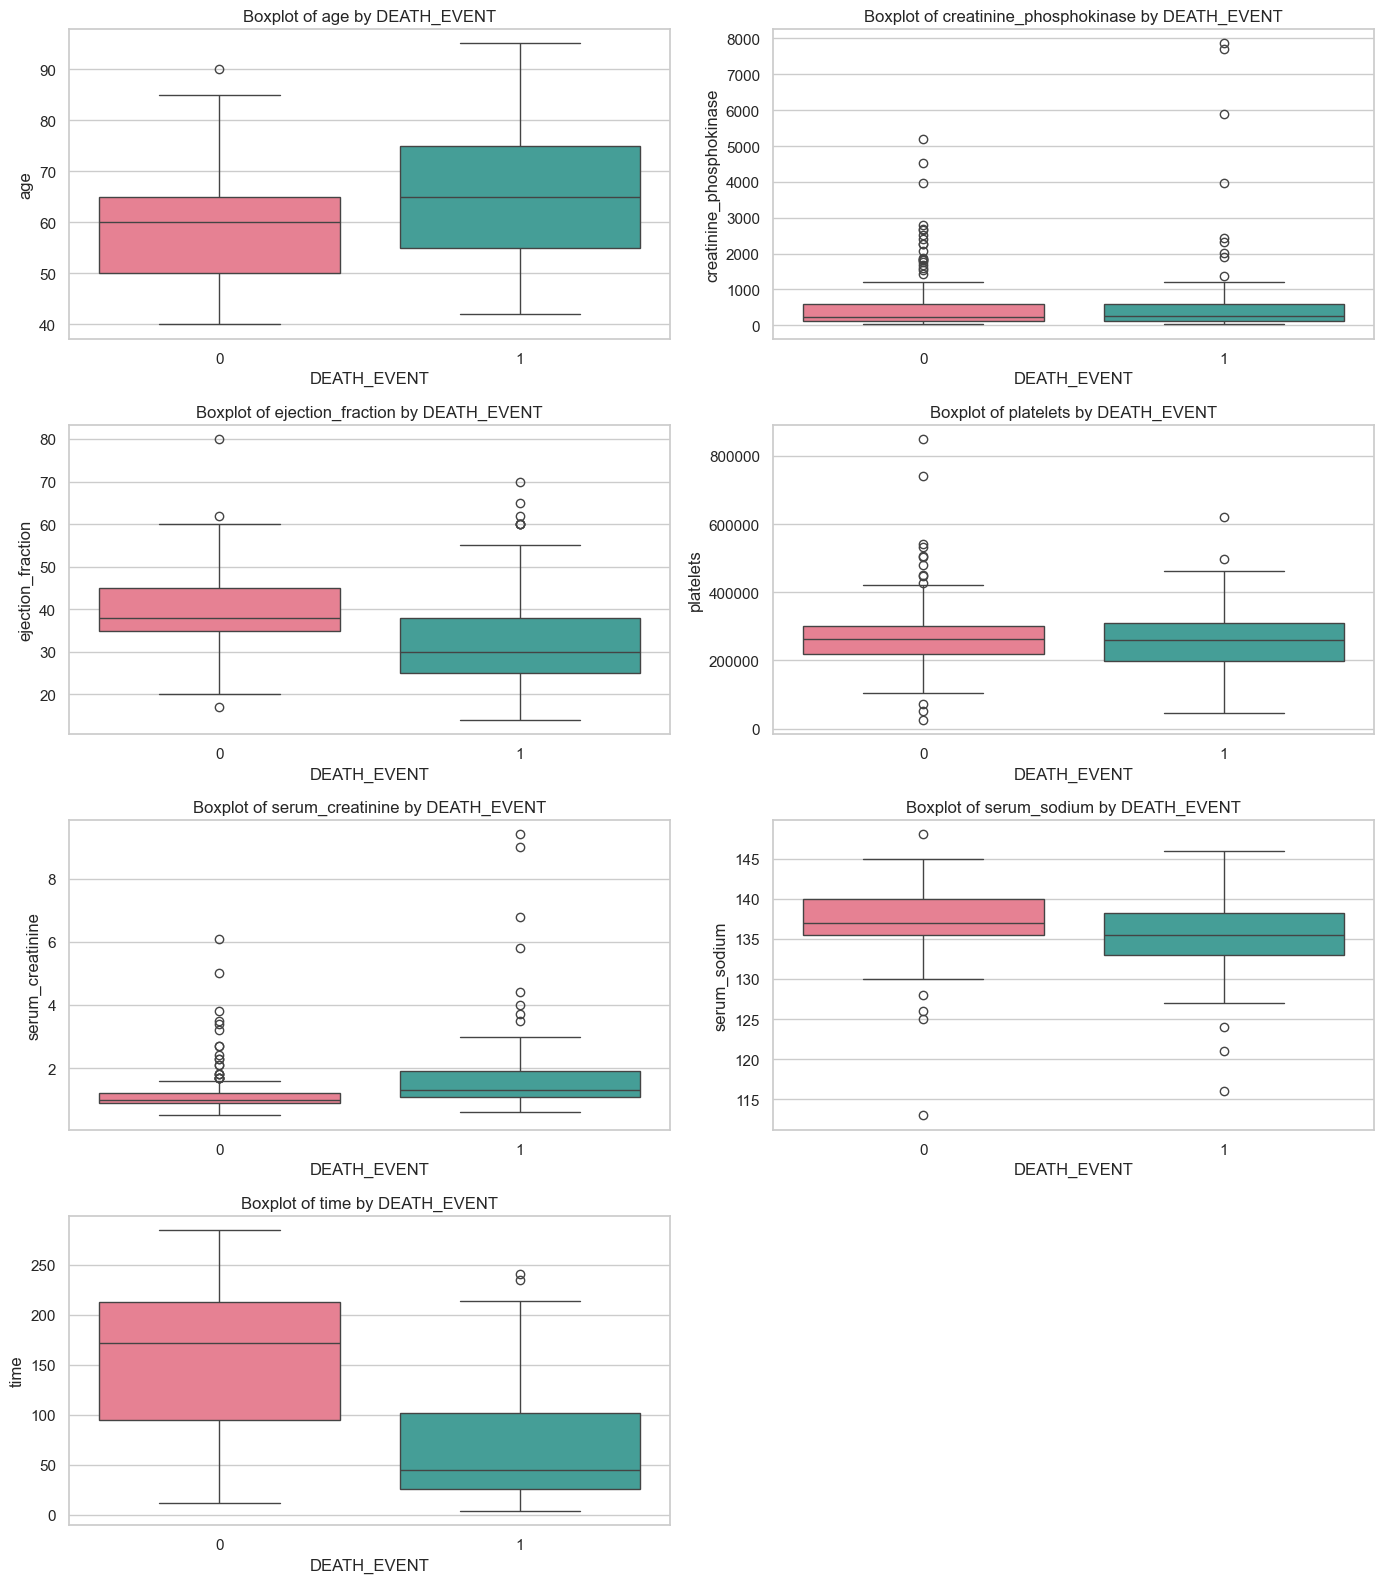

In [9]:
# Box plots of numerical features by target
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x="DEATH_EVENT", y=col, ax=ax, palette="husl")
    ax.set_title(f"Boxplot of {col} by DEATH_EVENT")
fig.delaxes(axes.flatten()[-1])
plt.tight_layout()
plt.show()

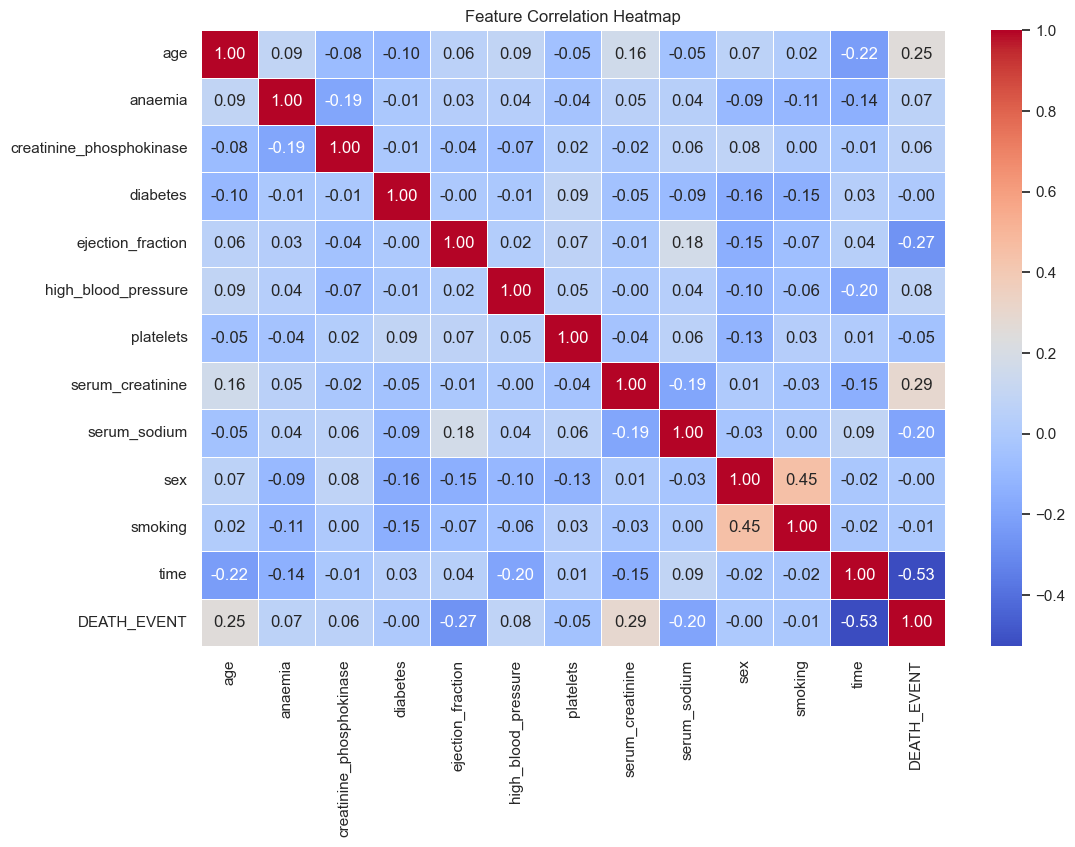

In [10]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Feature correlation with DEATH_EVENT:
time                       -0.53
serum_creatinine            0.29
ejection_fraction          -0.27
age                         0.25
serum_sodium               -0.20
high_blood_pressure         0.08
anaemia                     0.07
creatinine_phosphokinase    0.06
platelets                  -0.05
smoking                    -0.01
sex                        -0.00
diabetes                   -0.00
Name: DEATH_EVENT, dtype: float64


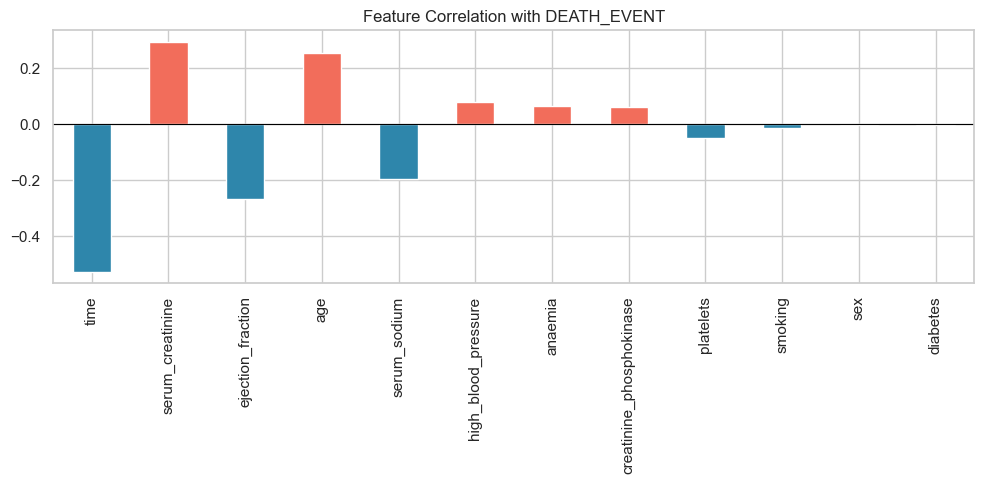

In [11]:
# Correlation with target (top features)
target_corr = corr["DEATH_EVENT"].drop("DEATH_EVENT").sort_values(key=abs, ascending=False)
print("Feature correlation with DEATH_EVENT:")
print(target_corr)

plt.figure(figsize=(10, 5))
target_corr.plot(kind="bar", color=["#F26D5B" if v > 0 else "#2E86AB" for v in target_corr])
plt.title("Feature Correlation with DEATH_EVENT")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

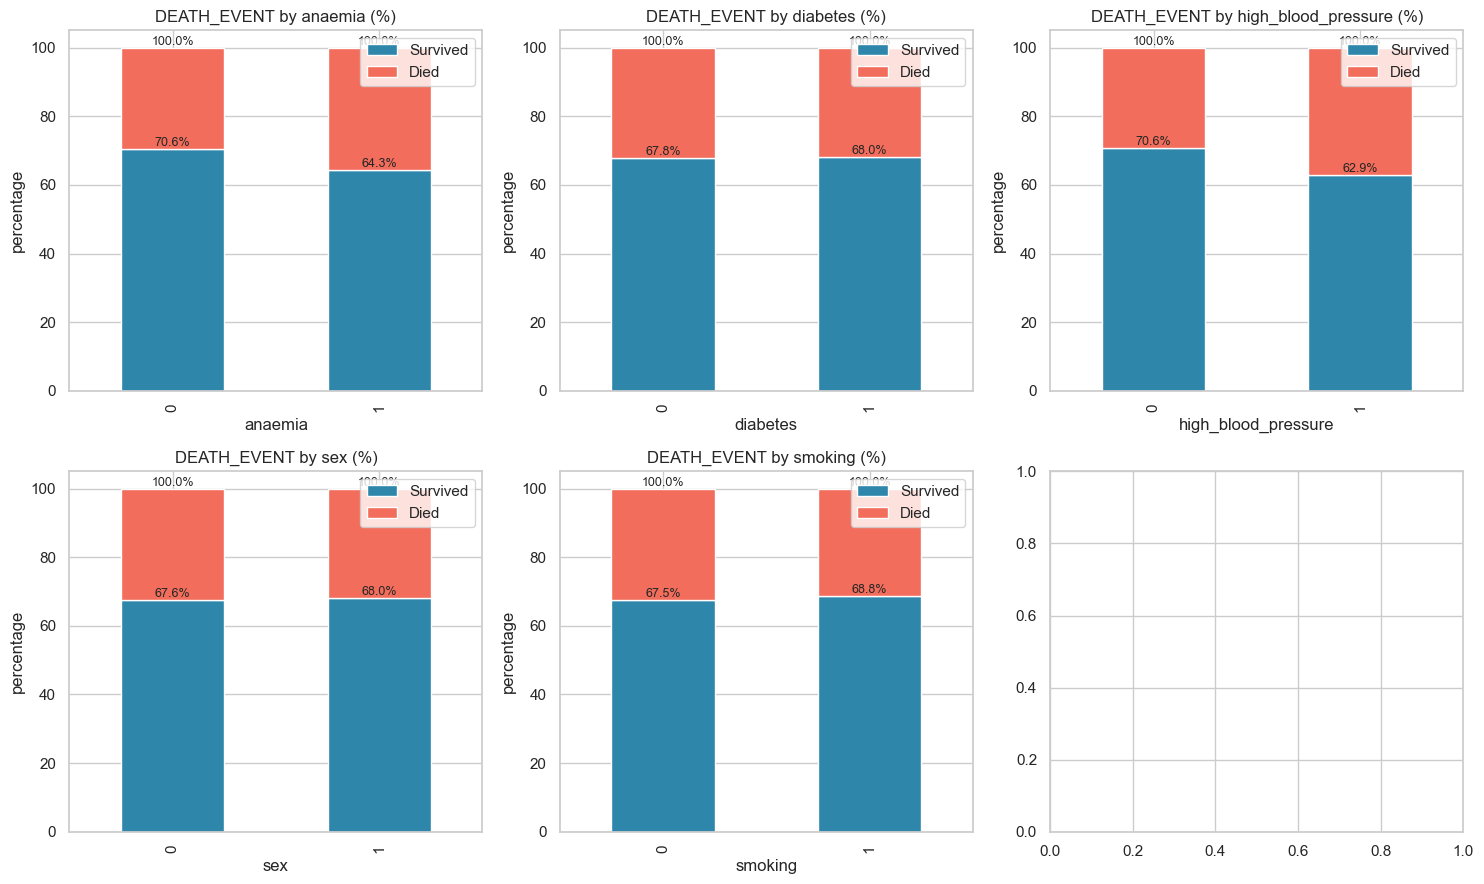

In [12]:
# Binary features vs target (death rate per group)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), binary_cols[:-1]):
    ct = pd.crosstab(df[col], df["DEATH_EVENT"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#2E86AB", "#F26D5B"])
    ax.set_title(f"DEATH_EVENT by {col} (%)")
    ax.set_ylabel("percentage")
    ax.legend(["Survived", "Died"], loc="upper right")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=9)
plt.tight_layout()
plt.show()

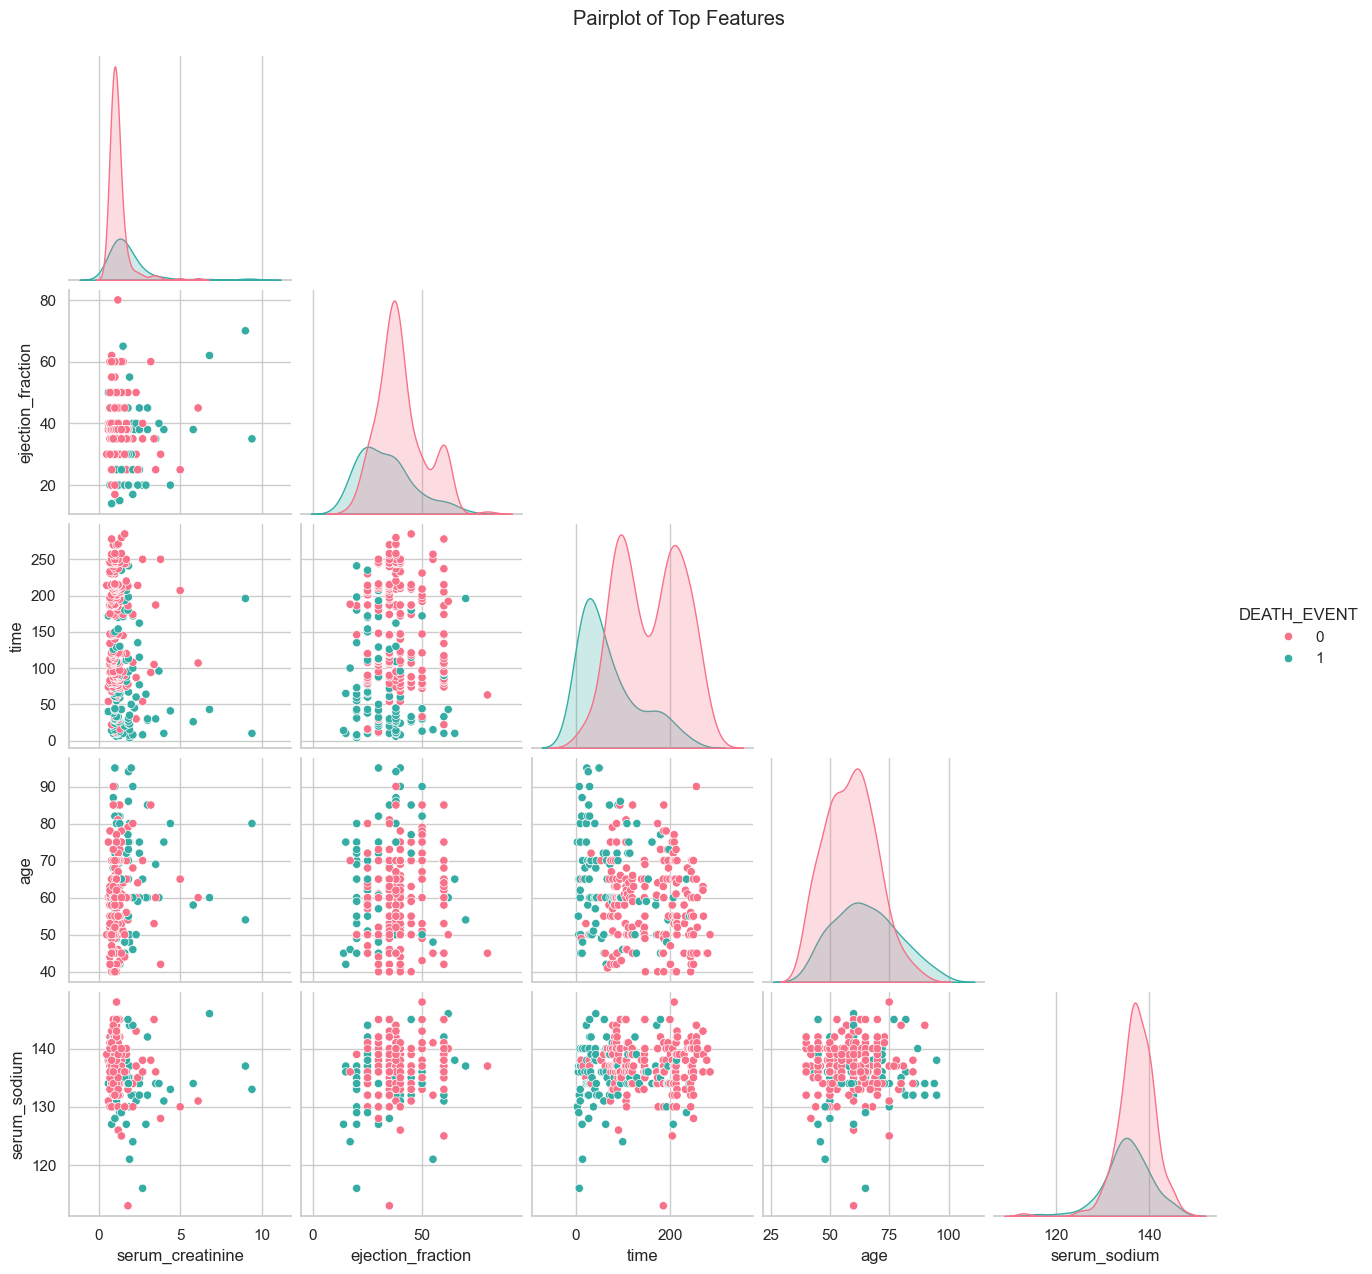

In [13]:
# Pairplot of top correlated features with target
top_feats = ["serum_creatinine", "ejection_fraction", "time", "age", "serum_sodium", "DEATH_EVENT"]
sns.pairplot(df[top_feats], hue="DEATH_EVENT", diag_kind="kde", palette="husl", corner=True)
plt.suptitle("Pairplot of Top Features", y=1.02)
plt.show()

### EDA Insights
- Dataset has **299 rows, 13 columns** (12 features + 1 target), no missing values.
- Target is **imbalanced**: ~32% died, ~68% survived.
- Strong predictors (correlation with `DEATH_EVENT`):
  - `serum_creatinine` (+), `ejection_fraction` (-), `time` (-), `age` (+).
- No strong multicollinearity among features.


## 3. Train/Test split

In [14]:
X = df.drop(columns=["DEATH_EVENT"])
y = df["DEATH_EVENT"]

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train target balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test target balance:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("StratifiedKFold(5, shuffle) ready.")

Train shape: (239, 12), Test shape: (60, 12)
Train target balance: {0: 0.678, 1: 0.322}
Test target balance:  {0: 0.683, 1: 0.317}
StratifiedKFold(5, shuffle) ready.


## 4. Model Building with a sklearn Pipeline

We build a **Pipeline**: `RobustScaler` (preprocessing) -> `Classifier` (model).
The pipeline is trained/predicted as one object, so raw features go in and predictions come out.


In [15]:
def make_pipeline(model):
    return Pipeline([("scaler", RobustScaler()), ("model", model)])

def evaluate_cv(pipeline, X, y, cv):
    scores_acc = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
    scores_roc = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")
    scores_f1 = cross_val_score(pipeline, X, y, cv=cv, scoring="f1")
    return scores_acc, scores_roc, scores_f1

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

rows = []
for name, model in models.items():
    pipe = make_pipeline(model)
    a, r, f = evaluate_cv(pipe, X_train, y_train, cv)
    rows.append({
        "Model": name,
        "CV-Accuracy": f"{a.mean():.4f} (+/- {a.std():.4f})",
        "CV-ROC-AUC": f"{r.mean():.4f} (+/- {r.std():.4f})",
        "CV-F1": f"{f.mean():.4f} (+/- {f.std():.4f})",
    })

results = pd.DataFrame(rows).sort_values("CV-ROC-AUC", ascending=False)
results

,Model,CV-Accuracy,CV-ROC-AUC,CV-F1
7,XGBoost,0.8413 (+/- 0.0480),0.9082 (+/- 0.0223),0.7439 (+/- 0.0655)
3,Random Forest,0.8539 (+/- 0.0555),0.9067 (+/- 0.0234),0.7683 (+/- 0.0820)
6,Gradient Boosting,0.8163 (+/- 0.0589),0.8936 (+/- 0.0316),0.7036 (+/- 0.0793)
4,Extra Trees,0.8329 (+/- 0.0388),0.8875 (+/- 0.0168),0.7067 (+/- 0.0651)
5,SVM (RBF),0.7864 (+/- 0.0320),0.8810 (+/- 0.0240),0.6398 (+/- 0.0704)
0,Logistic Regression,0.8411 (+/- 0.0500),0.8806 (+/- 0.0263),0.7373 (+/- 0.0793)
1,K-Nearest Neighbors,0.7492 (+/- 0.0307),0.7581 (+/- 0.0405),0.5147 (+/- 0.0686)
2,Decision Tree,0.7996 (+/- 0.0620),0.7541 (+/- 0.0676),0.6669 (+/- 0.1048)


## 5. Hyperparameter Tuning (on the Pipeline, via `model__` params)

### 5.1 RandomizedSearchCV for Gradient Boosting, Random Forest & XGBoost

In [16]:
param_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__min_samples_split": [2, 5, 10],
}

pipe_gb = make_pipeline(GradientBoostingClassifier(random_state=42))
rs_gb = RandomizedSearchCV(
    pipe_gb, param_gb, n_iter=60, cv=cv, scoring="roc_auc",
    random_state=42, n_jobs=-1, verbose=1
)
rs_gb.fit(X_train, y_train)
print("Best Gradient Boosting params:", rs_gb.best_params_)
print("Best CV ROC-AUC:", round(rs_gb.best_score_, 4))

Fitting 5 folds for each of 60 candidates, totalling 300 fits


Best Gradient Boosting params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__max_depth': 2, 'model__learning_rate': 0.01}
Best CV ROC-AUC: 0.9064


In [17]:
param_rf = {
    "model__n_estimators": [200, 500, 800],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
}

pipe_rf = make_pipeline(RandomForestClassifier(random_state=42))
rs_rf = RandomizedSearchCV(
    pipe_rf, param_rf, n_iter=60, cv=cv, scoring="roc_auc",
    random_state=42, n_jobs=-1, verbose=1
)
rs_rf.fit(X_train, y_train)
print("Best Random Forest params:", rs_rf.best_params_)
print("Best CV ROC-AUC:", round(rs_rf.best_score_, 4))

Fitting 5 folds for each of 60 candidates, totalling 300 fits


Best Random Forest params: {'model__n_estimators': 800, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 5, 'model__class_weight': 'balanced_subsample'}
Best CV ROC-AUC: 0.9213


In [18]:
param_xgb = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 6],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__reg_lambda": [0.1, 1, 10],
}

pipe_xgb = make_pipeline(XGBClassifier(eval_metric="logloss", random_state=42))
rs_xgb = RandomizedSearchCV(
    pipe_xgb, param_xgb, n_iter=60, cv=cv, scoring="roc_auc",
    random_state=42, n_jobs=-1, verbose=1
)
rs_xgb.fit(X_train, y_train)
print("Best XGBoost params:", rs_xgb.best_params_)
print("Best CV ROC-AUC:", round(rs_xgb.best_score_, 4))

Fitting 5 folds for each of 60 candidates, totalling 300 fits


Best XGBoost params: {'model__subsample': 1.0, 'model__reg_lambda': 0.1, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Best CV ROC-AUC: 0.9173


### 5.2 GridSearchCV fine-tune on best candidates

In [19]:
param_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"],
}

pipe_lr = make_pipeline(LogisticRegression(max_iter=2000, random_state=42))
gs_lr = GridSearchCV(
    pipe_lr, param_lr, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)
gs_lr.fit(X_train, y_train)
print("Best Logistic Regression params:", gs_lr.best_params_)
print("Best CV ROC-AUC:", round(gs_lr.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Logistic Regression params: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.8888


In [20]:
# Fine-tune Gradient Boosting around best RandomSearch region
best_gb = rs_gb.best_params_
gb_model_params = {k.replace("model__", ""): v for k, v in best_gb.items()}
param_gb_fine = {
    "model__n_estimators": [max(50, gb_model_params["n_estimators"] - 50), gb_model_params["n_estimators"], gb_model_params["n_estimators"] + 50],
    "model__learning_rate": [gb_model_params["learning_rate"] / 2, gb_model_params["learning_rate"], gb_model_params["learning_rate"] * 2],
    "model__max_depth": [max(2, gb_model_params["max_depth"] - 1), gb_model_params["max_depth"], gb_model_params["max_depth"] + 1],
    "model__min_samples_split": [2, 5, gb_model_params["min_samples_split"]],
}

pipe_gb2 = make_pipeline(GradientBoostingClassifier(random_state=42, subsample=gb_model_params["subsample"]))
gs_gb = GridSearchCV(
    pipe_gb2, param_gb_fine, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)
gs_gb.fit(X_train, y_train)
print("Best Gradient Boosting (tuned) params:", gs_gb.best_params_)
print("Best CV ROC-AUC:", round(gs_gb.best_score_, 4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits


Best Gradient Boosting (tuned) params: {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__min_samples_split': 10, 'model__n_estimators': 350}
Best CV ROC-AUC: 0.9076


## 6. Final Model Selection & Test Evaluation

In [21]:
# Collect tuned pipelines
tuned_pipelines = {
    "Logistic Regression (tuned)": gs_lr.best_estimator_,
    "Random Forest (tuned)": rs_rf.best_estimator_,
    "Gradient Boosting (tuned)": gs_gb.best_estimator_,
    "XGBoost (tuned)": rs_xgb.best_estimator_,
}

rows = []
for name, pipe in tuned_pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
    })

final_table = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
final_table

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest (tuned),0.83,0.80,0.63,0.71,0.90
2,Gradient Boosting (tuned),0.82,0.83,0.53,0.65,0.88
3,XGBoost (tuned),0.85,0.86,0.63,0.73,0.86
0,Logistic Regression (tuned),0.78,0.64,0.74,0.68,0.85


### Choose the best model (highest ROC-AUC on test)

In [22]:
best_name = final_table.iloc[0]["Model"]
best_pipeline = tuned_pipelines[best_name]
best_model = best_pipeline.named_steps["model"]
print(f"Best model on test set: {best_name}")
print(f"Pipeline steps: {list(best_pipeline.named_steps.keys())}")
print("\nBest model params:")
print(best_model.get_params())

Best model on test set: Random Forest (tuned)
Pipeline steps: ['scaler', 'model']

Best model params:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 800, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [23]:
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("=" * 60)
print("FINAL PIPELINE EVALUATION")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Survived (0)", "Died (1)"]))
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

FINAL PIPELINE EVALUATION
              precision    recall  f1-score   support

Survived (0)       0.84      0.93      0.88        41
    Died (1)       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60

Accuracy : 0.8333
Precision: 0.8000
Recall   : 0.6316
F1 Score : 0.7059
ROC-AUC  : 0.9012


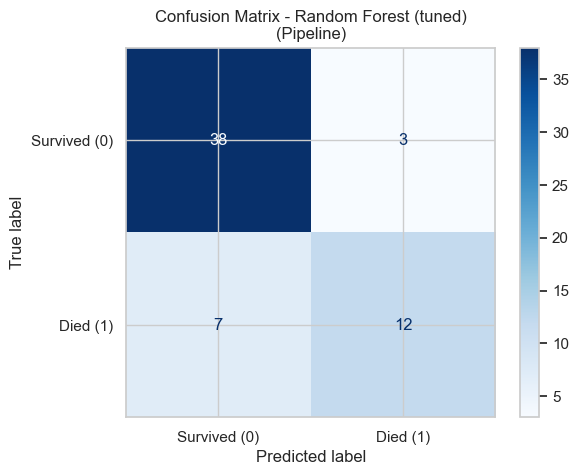

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived (0)", "Died (1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}\n({best_pipeline.__class__.__name__})")
plt.show()

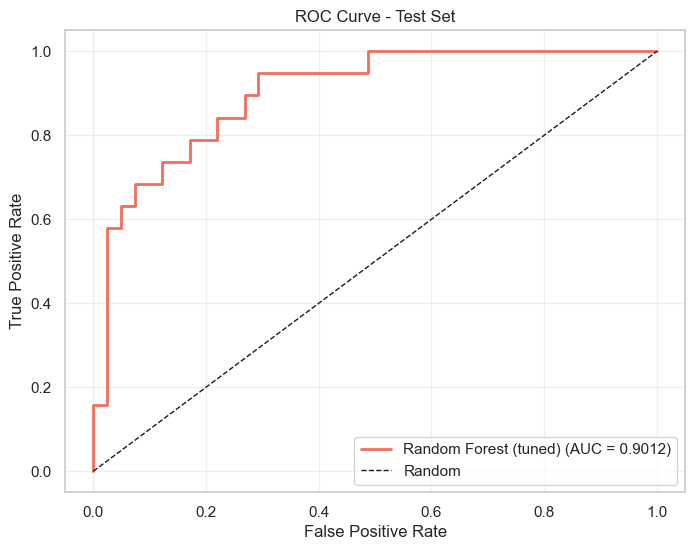

In [25]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, color="#F26D5B", label=f"{best_name} (AUC = {roc_auc_score(y_test, y_proba):.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

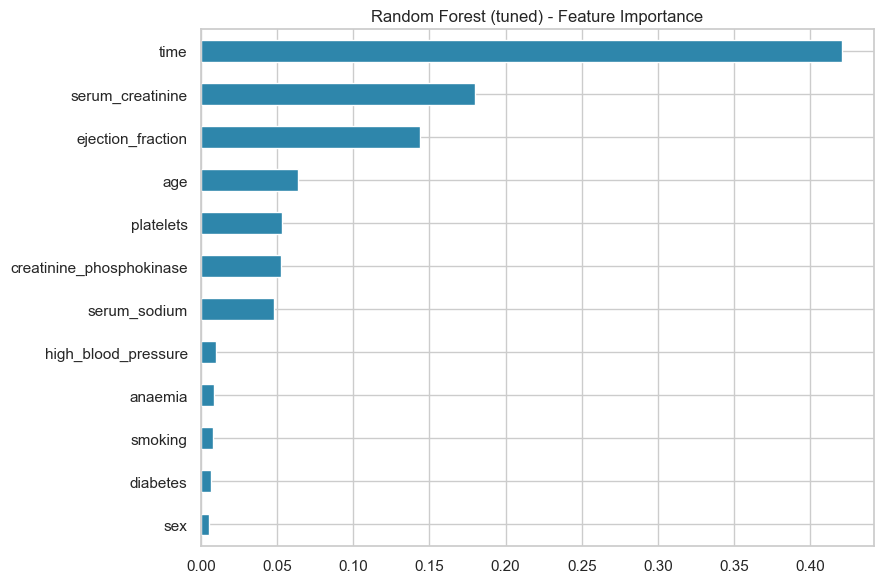

Top 5 features: ['time', 'serum_creatinine', 'ejection_fraction', 'age', 'platelets']


In [26]:
# Feature importance (extracted from the pipeline's model step)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
    plt.figure(figsize=(9, 6))
    importances.plot(kind="barh", color="#2E86AB")
    plt.title(f"{best_name} - Feature Importance")
    plt.tight_layout()
    plt.show()
    print("Top 5 features:", list(importances.index[::-1][:5]))

## 7. Save the full Pipeline with pickle (.pkl)

The entire **Pipeline (scaler + model)** is saved as ONE file: `pipeline.pkl`.
No separate scaler file is needed - the pipeline scales + predicts end-to-end.


In [27]:
# Fit pipeline on the full train set, then save
best_pipeline.fit(X_train, y_train)
with open("pipeline.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)
print("Saved: pipeline.pkl")
print("Files present:", [f for f in os.listdir(".") if f.endswith(".pkl")])

Saved: pipeline.pkl
Files present: ['pipeline.pkl']


## 8. Sample Predictions & Probability Check

In [28]:
# Load the saved pipeline back to verify it works end-to-end
with open("pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

print("Pipeline loaded from disk:")
print(loaded_pipeline)

# Pick 5 real samples from the test set (raw features - no manual scaling needed)
sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_df = X_test.iloc[sample_indices]

preds = loaded_pipeline.predict(X_test.iloc[sample_indices])
probas = loaded_pipeline.predict_proba(X_test.iloc[sample_indices])

print("\n--- SAMPLE TEST CASES (from unseen test set) ---")
print("=" * 100)
for i, idx in enumerate(sample_indices):
    actual = y_test.iloc[idx]
    print(f"\nSample #{i+1} (test row index {idx})")
    print("-" * 90)
    print(sample_df.iloc[i].to_string())
    print(f"\nActual DEATH_EVENT             : {actual}")
    print(f"Predicted DEATH_EVENT          : {preds[i]}")
    print(f"Probability [survived, died]   : {probas[i]}")
    print(f"P(death) = {probas[i][1]:.4f} -> {'HIGH RISK (>0.5)' if probas[i][1] > 0.5 else 'LOW RISK'}")
print("=" * 100)

Pipeline loaded from disk:
Pipeline(steps=[('scaler', RobustScaler()),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=5, min_samples_leaf=4,
                                        min_samples_split=10, n_estimators=800,
                                        random_state=42))])

--- SAMPLE TEST CASES (from unseen test set) ---

Sample #1 (test row index 34)
------------------------------------------------------------------------------------------
age                            42.00
anaemia                         0.00
creatinine_phosphokinase      102.00
diabetes                        1.00
ejection_fraction              40.00
high_blood_pressure             0.00
platelets                  237000.00
serum_creatinine                1.20
serum_sodium                  140.00
sex                             1.00
smoking                         0.00
time                           74.00

### 8.1 Predict a brand-new (hypothetical) patient (raw features -> pipeline -> output)

In [29]:
# Age, Anaemia, CPK, Diabetes, EF, HBP, Platelets, Serum-Creatinine, Serum-Sodium, Sex, Smoking, Time(days)
new_patient = [[65, 1, 180, 0, 20, 1, 250000, 1.9, 130, 1, 0, 10]]
new_patient_df = pd.DataFrame(new_patient, columns=X.columns)

proba = loaded_pipeline.predict_proba(new_patient_df)
pred = loaded_pipeline.predict(new_patient_df)

print("New patient feature vector:", new_patient)
print(f"\nPrediction: {'DEATH' if pred[0] == 1 else 'SURVIVE'}")
print(f"P(survived) = {proba[0][0]:.4f}")
print(f"P(death)    = {proba[0][1]:.4f}")
print(f"Risk Level  : {'HIGH RISK' if proba[0][1] > 0.5 else 'LOW RISK'}")

New patient feature vector: [[65, 1, 180, 0, 20, 1, 250000, 1.9, 130, 1, 0, 10]]

Prediction: DEATH
P(survived) = 0.0740
P(death)    = 0.9260
Risk Level  : HIGH RISK
